# Aufgabe 3

In Aufgabe zwei wurde dass Inferferenzmuster von zwei verscheidnene LEDs, bei uns einer grünen und roten LED. Es wurden vier Interferenzmuster als Bilderaufgenommen. Mit der gleichen Software die in Aufgabe 1 und 2 benutzt wurde.

Um die Abstände in der Software zu kallebrieren, wurde viermal, das Bild um 1mm verschoben. Dabei wurde ein bestimmter Punkt, oftmals ein Staubkorn oder eine andere Verschmutzung genommen und die Pixel zwischen den Punkt bei 77mm und 78mm ermittelt in dem Bild. So erhält man, das Verhältnis zwischen Pixel und Millimeter um die Daten auswerten zu können.

Messung| Tischpos [mm] ($\pm 200nm$) |Pixel x-Achse | Pixel y-Achse | Tischpos [mm] ($\pm 200nm$) | Pixel x-Achse | Pixel y-Achse | x-Abstand |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
1|77|2.153|1.113|78|1.386|1.110|767
2|77|1.701|971|78|931|965|770
3|77|2.131|635|78|1.368|629|763
4|77|1.907|1.713|78|1.137|1.704|770

: Die ermittelten Pixelpositionen der Orientierungspunkte bei den Tsichpositionen 77mm und 78mm welche jeweils die Unsicherheit von ($\pm 200nm$) hatten.

Wenn wir den Mittelwert nehmen, des x-Abstands aus der Tabelle. Erhalten wir, dass vorlgende Verhältnis von Pixel zu Millimeter.

$$1\text{mm} \overset{\wedge}{=} 767.5 ~\text{Pixel}$$

Wir wollten eigentlich ursprünglich 5 Messungen machen, jedoch war dies nicht zu bewerkstelligen. Da die Software und Kamera immer wieder keine Bilder gezeigt haben oder gar ganz eingefrohren sind.

#### Ermittelte Beugungsbilder für die LEDs

![Beugungsbild der roten LED, mit dem ersten Maxima zentriert mit Maßstaab (Rot) und der Betrachtungslinie in Pfeilrichtung (gelb)](./figures/Aufgabe_3_1.png)

![Beugungsbild der roten LED, mit vielen Maxima und Minimas mit Maßstaab (Rot) und der Betrachtungslinie in Pfeilrichtung (gelb)](./figures/Aufgabe_3_2.png)

![Beugungsbild der grünen LED, mit dem ersten Maxima zentriert mit Maßstaab (Rot) und der Betrachtungslinie in Pfeilrichtung (gelb)](./figures/Aufgabe_3_3.png)

![Beugungsbild der grünen LED, mit vielen Maxima und Minimas mit Maßstaab (Rot) und der Betrachtungslinie in Pfeilrichtung (gelb)](./figures/Aufgabe_3_4.png)

#### Diagramm mit den Intensitäten und dem Fit

C:\Users\vd01p\AppData\Local\Temp\ipykernel_7592\3657011949.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


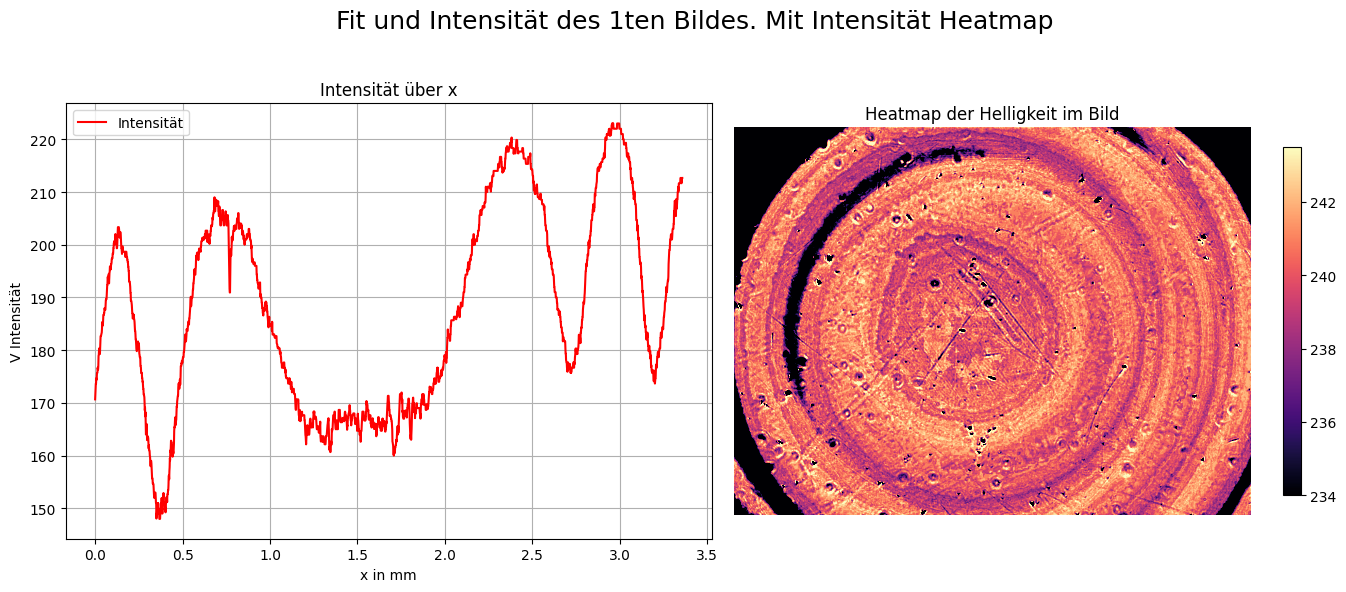

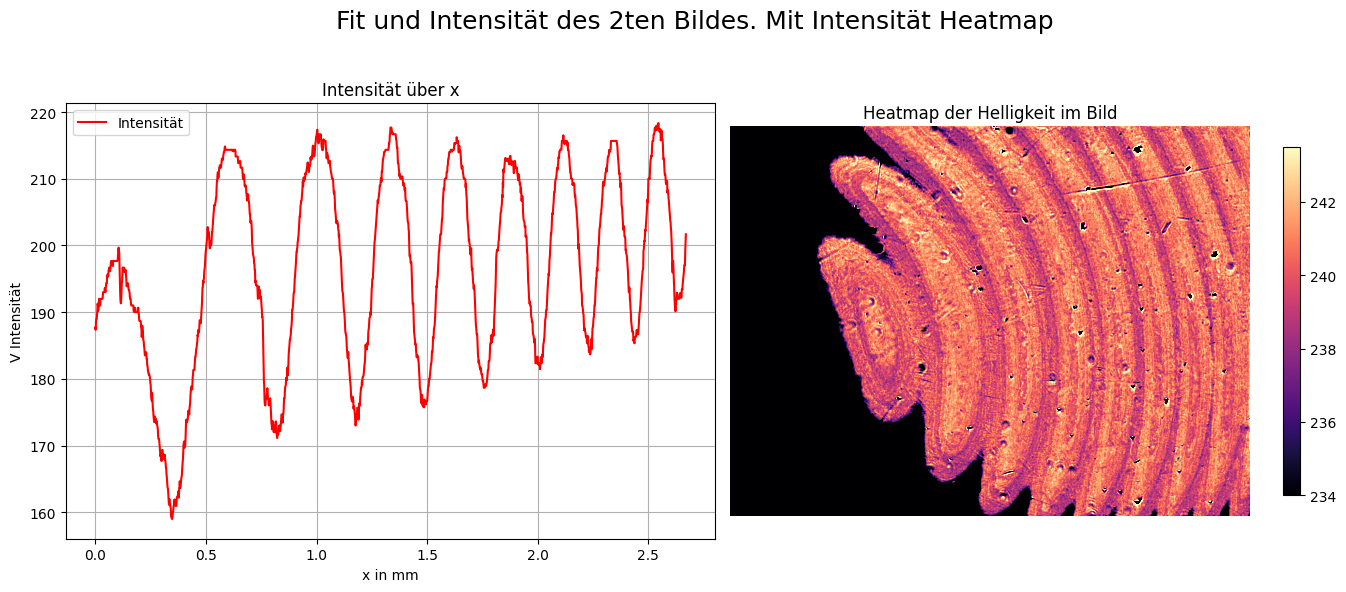

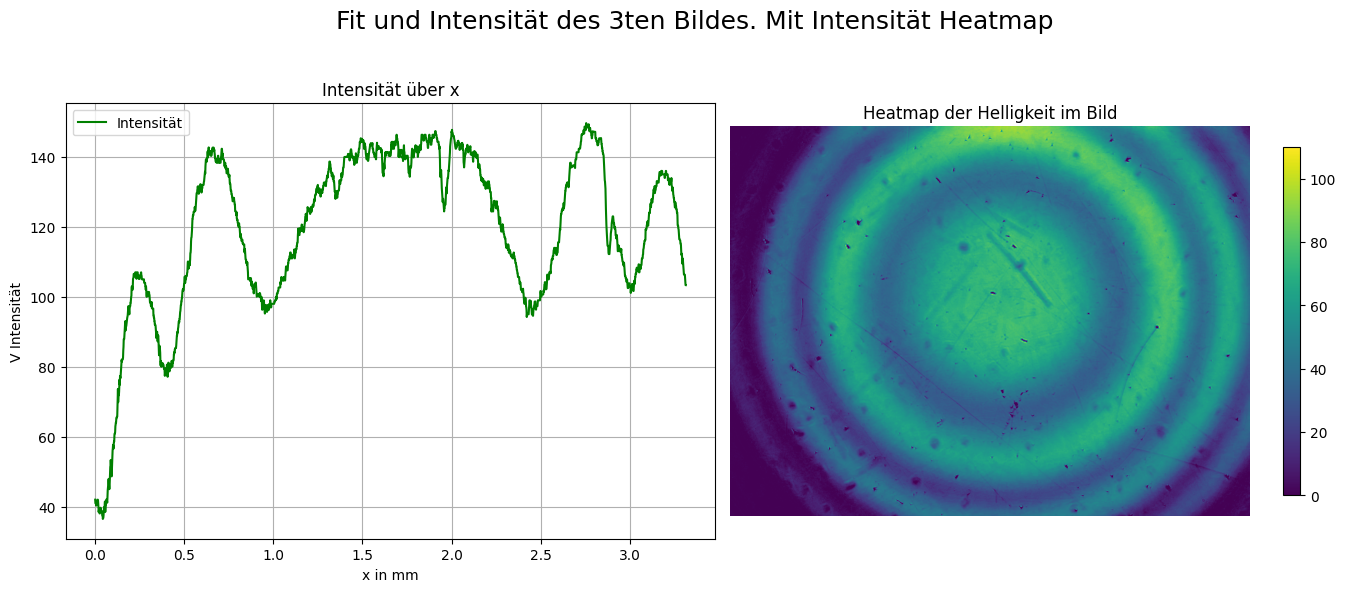

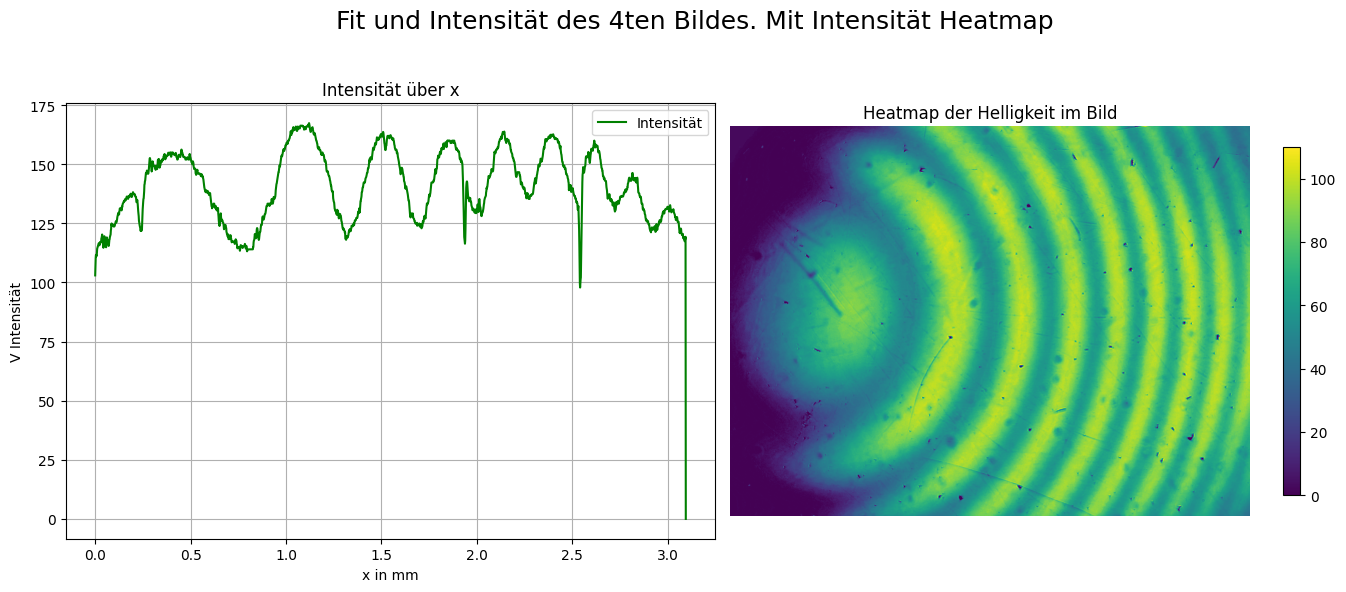

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

for i in range(4):
    df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep="\t")
    img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
    lum_img = img[:, :, 0] # Luminosity

    LED = "roter" if i < 2 else "grüner"

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Fit und Intensität des {i+1}ten Bildes. Mit Intensität Heatmap", fontsize=18)

    # linkes Plot: Intensität über x
    ax0 = axes[0]
    ax0.plot(df['X']/767.5, df['Y'], label="Intensität", color=LED[0])
    ax0.set_title("Intensität über x")
    ax0.set_xlabel("x in mm")
    ax0.set_ylabel("V Intensität")
    ax0.grid(True)
    ax0.legend()

    # rechtes Plot: Heatmap der Helligkeit
    ax1 = axes[1]
    im = ax1.imshow(lum_img, cmap=("magma" if i < 2 else "viridis"))
    ax1.set_title("Heatmap der Helligkeit im Bild")
    ax1.axis("off")
    if i < 2:
        im.set_clim(234, 243.5)
    else:
        im.set_clim(0, 110)
    fig.colorbar(im, ax=ax1, shrink=0.8)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Fehlerbetrachtung
**Klassische Feherbetrachtung** (Nicht genaues MEssen, schumtzgige Linesn, kein perfekter aufbau, und die Kamera war um 1px auf 1mm angeschrägt, aber dass war nicht korrigierbar weil sonnst wahrscheinlich eine größer abweichung passiert wäre)

Man muss zudem auch noch erwähnen, dass es nicht einfach war die Interferenzmuster wirklich sichbar zu machen, da wir nicht genau gewusst hatten wo genau sich die Diode in der LED befand. Mussen wir die Apperatur wodie LEDs befestigt waren, sehr lange verschieben und drehen um den richtigen Winkel bekommen. Uns ist zudem aufgefallen, dass die LED die besten Muster gegeben hatte, wenn die leicht schräg von oben auf die Linsen draufgeschienen hat.
Zudem hatten wir sehr lange Probleme überhaupt Interferenzmuster zu erhalten, bei den zwei LEDs. Erst nach mehrmaligen Wechseln der Linsen und neustarts der Software gelang es uns die guten Bilder zu machen.

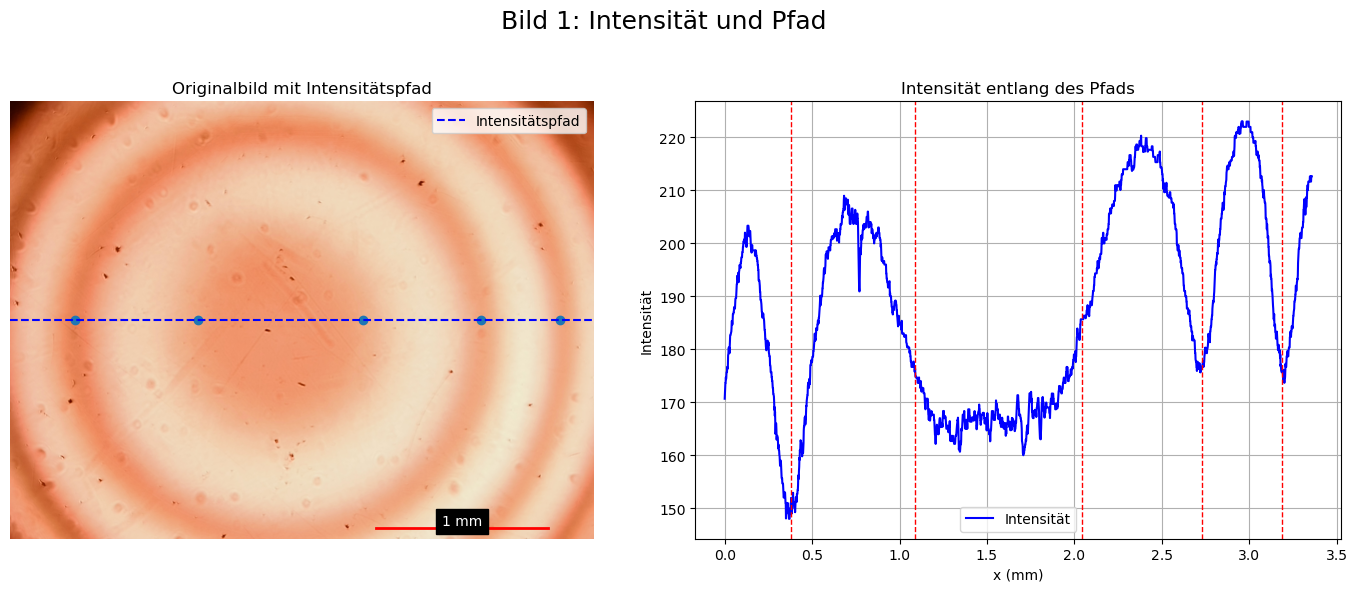

972


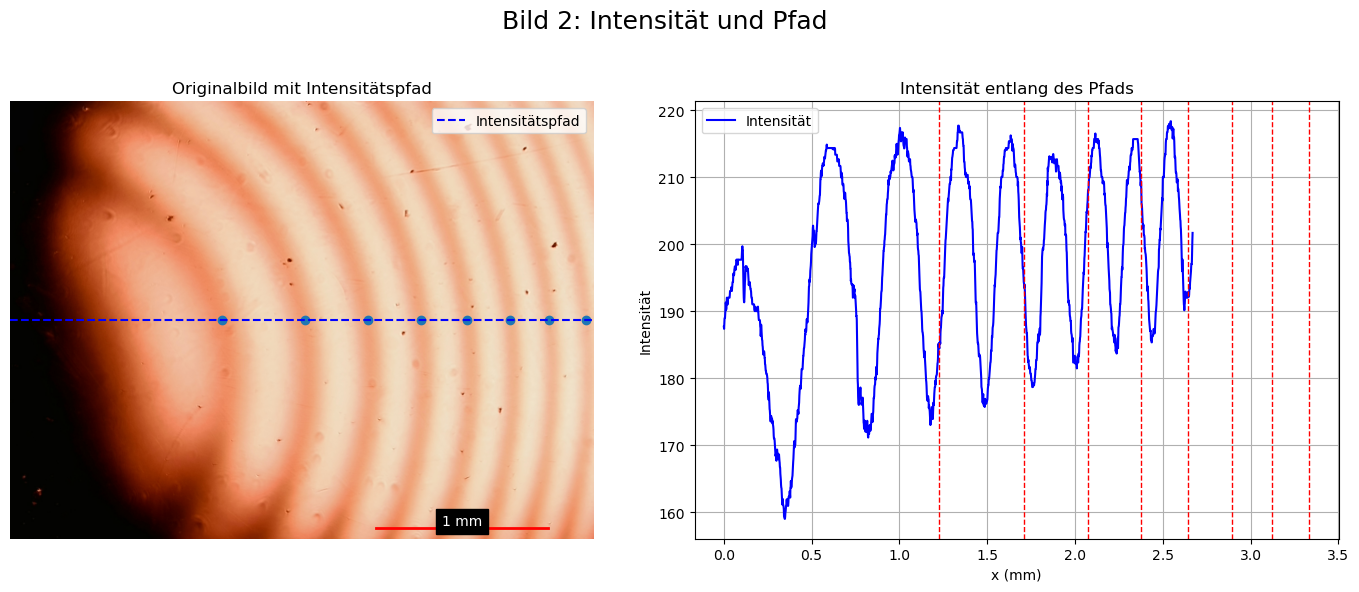

972


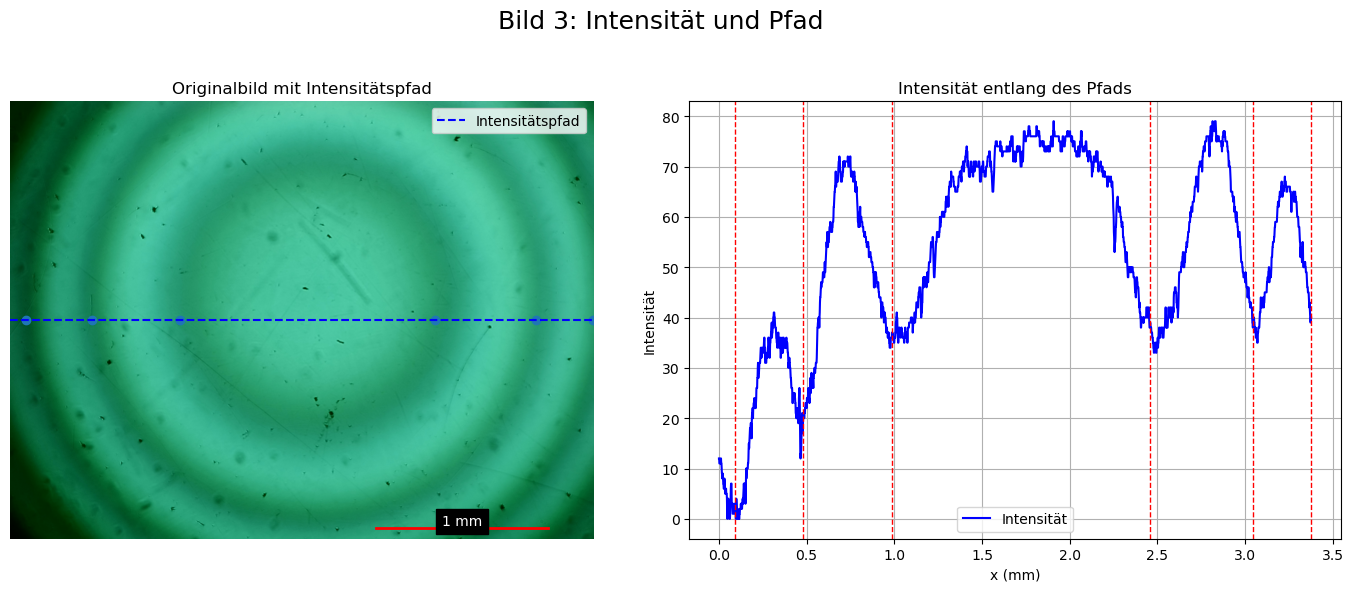

972


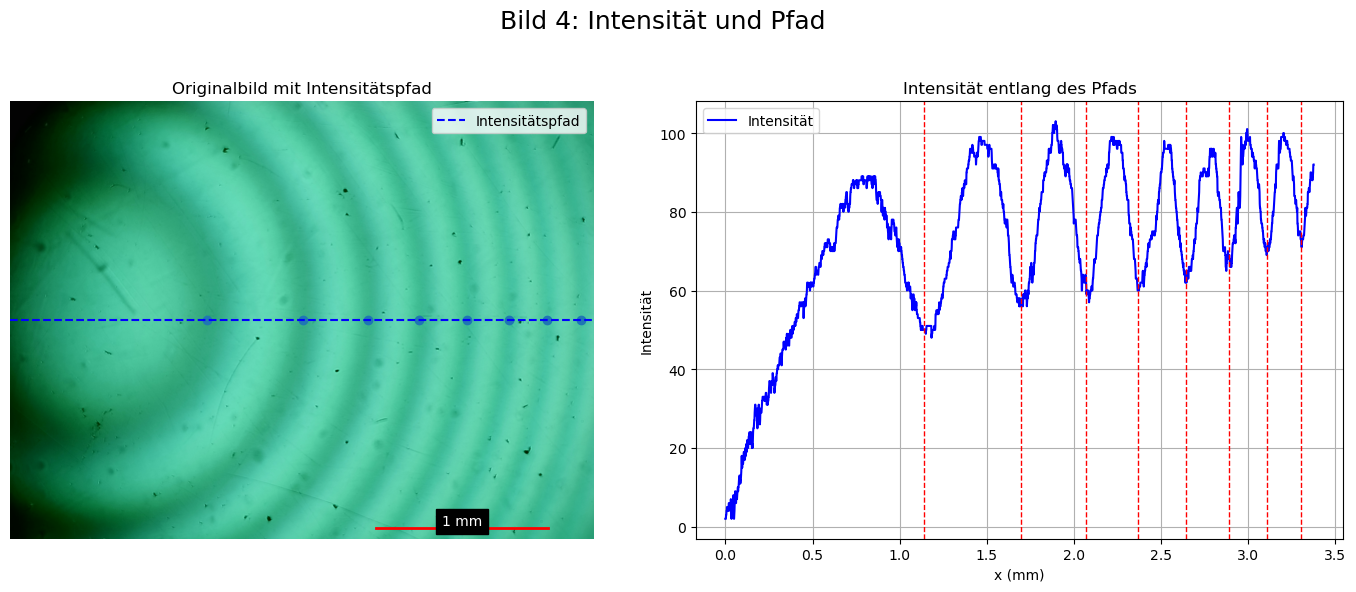

972


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

min_ausgelesen = [[290, 836, 1570, 2095, 2445], [941, 1312, 1590, 1825, 2031, 2222, 2395, 2560], [70, 366, 757, 1888, 2338, 2590], [875, 1301, 1589, 1817, 2030, 2217, 2387, 2536]]

# Funktion zum Zeichnen des Maßstabs
def draw_scale(ax, scale_length_pixels, scale_length_mm, image_shape):
    scale_bar_x = image_shape[1] - 200  # Abstand vom rechten Rand
    scale_bar_y = image_shape[0] - 50   # Abstand vom unteren Rand
    ax.plot([scale_bar_x, scale_bar_x - scale_length_pixels], [scale_bar_y, scale_bar_y], color='red', lw=2)
    ax.text(scale_bar_x - scale_length_pixels / 2, scale_bar_y - 10, f'{scale_length_mm} mm', color='white',
            ha='center', fontsize=10, backgroundcolor='black')

# Daten für die Bilder und Intensitäten
for i in range(4):
    df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep="\t")
    # Bild laden
    img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
    lum_img = img[:, :, 0]  # Luminosity

    # Startpunkt für die Linie (Standard: Mitte des Bildes)
    center_y = lum_img.shape[0] // 2
    start_x = 0  # Standard: von x = 0 starten

    # Intensitätslinie aus der Mitte des Bildes extrahieren
    intensity_line = lum_img[center_y, start_x:]

    # Plot erstellen
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Bild {i+1}: Intensität und Pfad", fontsize=18)

    # Linkes Bild: Originalbild mit eingezeichneter Linie und Maßstab
    ax0 = axes[0]
    ax0.imshow(img)
    ax0.axhline(center_y, color='blue', linestyle='--', label='Intensitätspfad')
    draw_scale(ax0, scale_length_pixels=767.5, scale_length_mm=1, image_shape=lum_img.shape)
    ax0.set_title("Originalbild mit Intensitätspfad")
    ax0.axis("off")
    ax0.scatter(min_ausgelesen[i], np.full(len(min_ausgelesen[i]), center_y))
    ax0.legend()

    ax1 = axes[1]
    if i > 1:
        # Rechtes Bild: Intensität entlang der Linie
        x_mm = np.arange(len(intensity_line)) / 767.5  # Pixel in mm umrechnen
        ax1.plot(x_mm, intensity_line, color='blue', label='Intensität')
    else:
        ax1.plot(df['X']/767.5, df['Y'], color='blue', label="Intensität")

    ax1.set_title("Intensität entlang des Pfads")
    ax1.set_xlabel("x (mm)")
    # Vertikale Linien an den ausgelesenen x-Positionen (Pixel -> mm)
    for px in min_ausgelesen[i]:
        x_mm_pos = (px - start_x) / 767.5
        ax1.axvline(x=x_mm_pos, color='red', linestyle='--', linewidth=1)
    ax1.set_ylabel("Intensität")
    ax1.grid(True)
    ax1.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print(center_y)